In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [4]:
rfm = pd.read_csv("rfm_features.csv")

In [5]:
rfm

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,67,15,-64.68,3,5,1,351
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,4,2646.99,3,3,5,335
4,12351,11,1,300.93,5,1,2,512
...,...,...,...,...,...,...,...,...
4378,18283,18,6,641.77,4,4,3,443
4379,18284,65,2,436.68,3,3,2,332
4380,18285,296,1,427.00,1,2,2,122
4381,18286,112,3,1188.43,2,3,4,234


In [6]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,67,15,-64.68,3,5,1,351
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,4,2646.99,3,3,5,335
4,12351,11,1,300.93,5,1,2,512


In [9]:
rfm.info

<bound method DataFrame.info of       Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0           12346       67         15    -64.68        3        5        1   
1           12347        3          2   1323.32        5        2        4   
2           12348       74          1    222.16        2        1        1   
3           12349       43          4   2646.99        3        3        5   
4           12351       11          1    300.93        5        1        2   
...           ...      ...        ...       ...      ...      ...      ...   
4378        18283       18          6    641.77        4        4        3   
4379        18284       65          2    436.68        3        3        2   
4380        18285      296          1    427.00        1        2        2   
4381        18286      112          3   1188.43        2        3        4   
4382        18287       18          5   2340.61        4        4        5   

      RFM_Score  
0           3

In [11]:
rfm.isnull().sum()

Customer ID    0
Recency        0
Frequency      0
Monetary       0
R_Score        0
F_Score        0
M_Score        0
RFM_Score      0
dtype: int64

In [12]:
rfm.dropna(inplace=True)

In [13]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
count,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000
mean,15350.611453,91.395163,5.381474,1904.679118,3.028519,3.000000,3.000000,335.851928
std,1700.737934,98.176493,10.051921,8519.369281,1.432606,1.414536,1.414536,151.427544
min,12346.000000,1.000000,1.000000,-25111.090000,1.000000,1.000000,1.000000,111.000000
25%,13880.500000,17.000000,1.000000,285.260000,2.000000,2.000000,2.000000,221.000000
50%,15354.000000,52.000000,3.000000,655.940000,3.000000,3.000000,3.000000,333.000000
75%,16837.000000,138.000000,6.000000,1645.690000,4.000000,4.000000,4.000000,455.000000
max,18287.000000,374.000000,270.000000,341776.730000,5.000000,5.000000,5.000000,555.000000


In [14]:
X = rfm[['Recency','Frequency','Monetary']]

In [15]:
X

,Recency,Frequency,Monetary
0,67,15,-64.68
1,3,2,1323.32
2,74,1,222.16
3,43,4,2646.99
4,11,1,300.93
...,...,...,...
4378,18,6,641.77
4379,65,2,436.68
4380,296,1,427.00
4381,112,3,1188.43


In [16]:
X.head()

,Recency,Frequency,Monetary
0,67,15,-64.68
1,3,2,1323.32
2,74,1,222.16
3,43,4,2646.99
4,11,1,300.93


In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [19]:
print(X_scaled[:5])

[[-0.24851108  0.95699354 -0.23118892]
 [-0.90047267 -0.33643914 -0.06824748]
 [-0.17720278 -0.43593396 -0.19751592]
 [-0.49299668 -0.1374495   0.08714208]
 [-0.81897747 -0.43593396 -0.18826888]]


In [20]:
inertia=[]

for k in range(2,11):

    model=KMeans(n_clusters=k,random_state=42)

    model.fit(X_scaled)

    inertia.append(model.inertia_)

In [21]:
inertia

[9465.059763539626,
 5357.474305340247,
 3984.821516365064,
 2953.2263837977725,
 2503.3553411978037,
 1946.3044165206027,
 1573.1536788574817,
 1388.4683194266859,
 1294.126189515148]

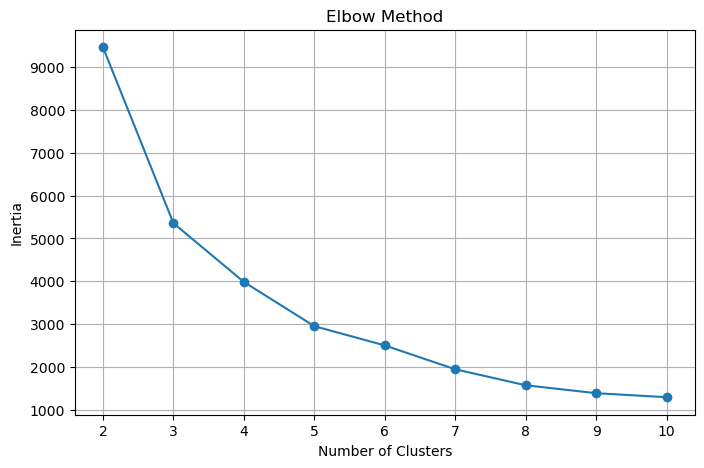

In [22]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11),inertia,marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [23]:
kmeans=KMeans(n_clusters=4,random_state=42)

rfm['KMeans_Cluster']=kmeans.fit_predict(X_scaled)

In [24]:
kmeans

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [25]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,KMeans_Cluster
0,12346,67,15,-64.68,3,5,1,351,0
1,12347,3,2,1323.32,5,2,4,524,0
2,12348,74,1,222.16,2,1,1,211,0
3,12349,43,4,2646.99,3,3,5,335,0
4,12351,11,1,300.93,5,1,2,512,0


In [26]:
rfm['KMeans_Cluster'].value_counts()

KMeans_Cluster
0    3180
1    1072
3     122
2       9
Name: count, dtype: int64

In [27]:
cluster_summary=rfm.groupby('KMeans_Cluster')[['Recency','Frequency','Monetary']].mean()

cluster_summary

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,42.936792,4.967610,1480.167565
1,244.847015,1.902052,406.926366
2,4.888889,137.000000,141906.437778
3,12.508197,37.032787,15802.399287


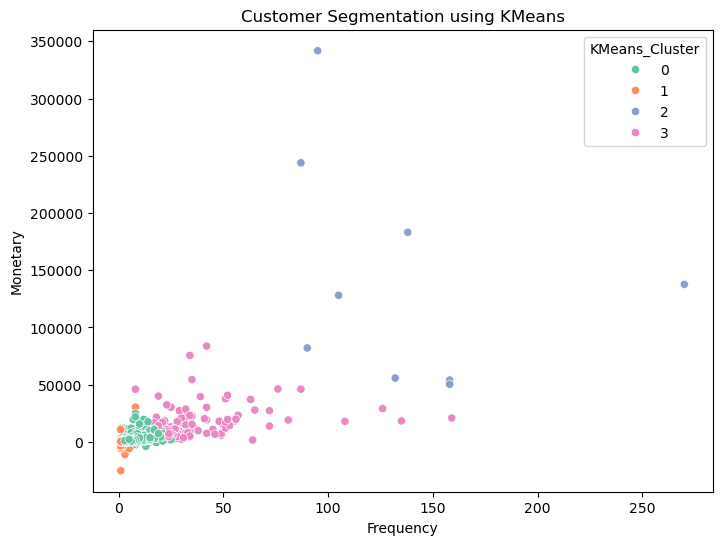

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='KMeans_Cluster',
    data=rfm,
    palette='Set2'
)

plt.title("Customer Segmentation using KMeans")

plt.show()

In [29]:
score=silhouette_score(X_scaled,rfm['KMeans_Cluster'])

print(score)

0.6152511799112869


In [30]:
dbscan=DBSCAN(eps=0.8,min_samples=5)

rfm['DBSCAN_Cluster']=dbscan.fit_predict(X_scaled)